In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load the dataset
df = pd.read_csv("../data/sl_economic_crisis_data.csv")
df.head()

,USD_Rate,Diesel_Price_Rs,Petrol_Price_Rs,Lorry_Quota_L,Bike_Quota_L,Rice_Price_Rs,Bread_Price_Rs,Power_Cut_Hours,Economic_Status,Power_Cut_Warning
0,320.70,402.80,415.42,150.0,6.0,236.65,129.86,0,Moderate_Stress,0
1,311.18,387.10,402.38,156.0,6.0,229.10,128.31,0,Normal,0
2,322.97,392.01,404.04,158.0,6.0,226.47,129.63,0,Normal,0
3,336.10,400.04,414.50,169.0,7.0,239.23,133.59,3,Moderate_Stress,1
4,309.74,383.18,389.71,163.0,5.0,233.37,128.95,0,Normal,0


In [9]:
df.columns


Index(['USD_Rate', 'Diesel_Price_Rs', 'Petrol_Price_Rs', 'Lorry_Quota_L',
       'Bike_Quota_L', 'Rice_Price_Rs', 'Bread_Price_Rs', 'Power_Cut_Hours',
       'Economic_Status', 'Power_Cut_Warning'],
      dtype='str')

C:\Users\DHANUwa\AppData\Local\Temp\ipykernel_11924\1006761653.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Economic_Status', palette='viridis', ax=axes[0, 0])
C:\Users\DHANUwa\AppData\Local\Temp\ipykernel_11924\1006761653.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Power_Cut_Warning', y='USD_Rate', palette='Set2', ax=axes[1,0])
C:\Users\DHANUwa\AppData\Local\Temp\ipykernel_11924\1006761653.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['No Power Cut (0)', 'Power Cut Expected (1)'])


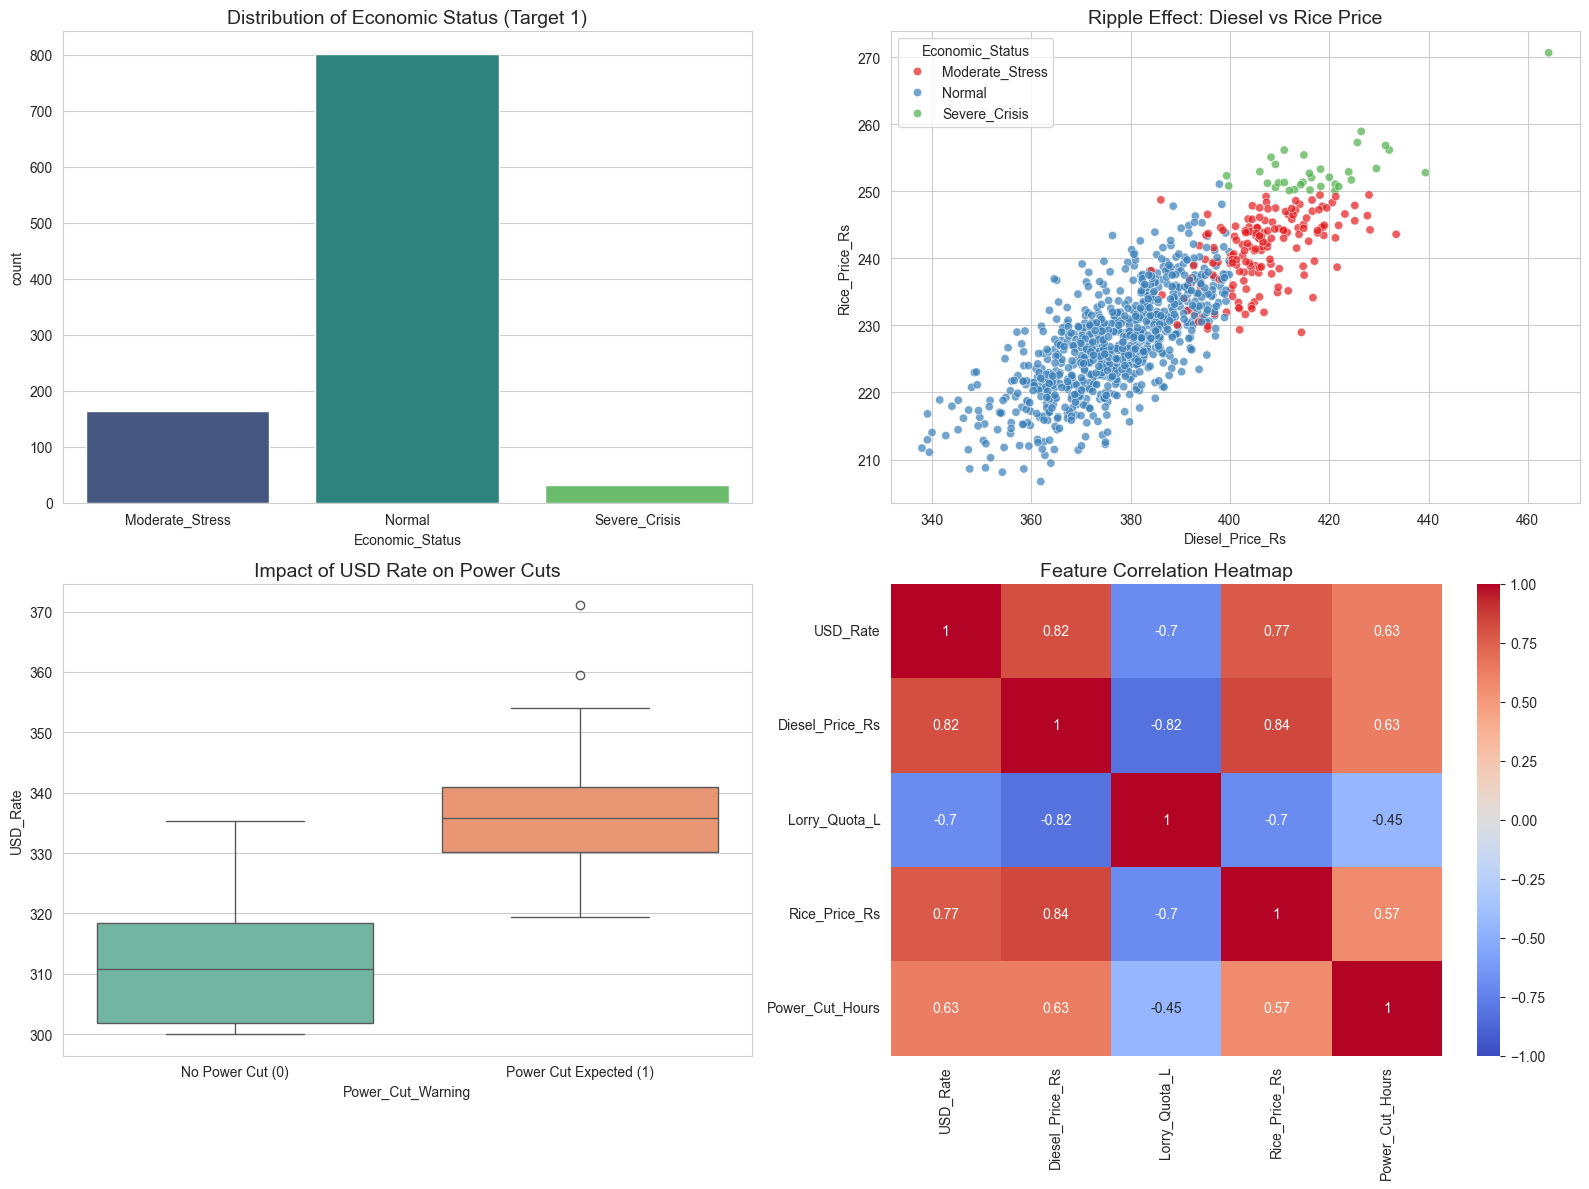

In [3]:
# ප්‍රස්ථාර සඳහා Style එකක් සැකසීම
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Target Class Balance (පන්ති බෙදී ඇති ආකාරය) ---
# ML වලදී පන්ති සමබරද කියලා බලන්නම ඕනේ.
sns.countplot(data=df, x='Economic_Status', palette='viridis', ax=axes[0, 0])
axes[0,0].set_title('Distribution of Economic Status (Target 1)', fontsize=14)

# --- Plot 2: Ripple Effect (ඩීසල් සහ සහල් මිල අතර සම්බන්ධය) ---
sns.scatterplot(data=df, x='Diesel_Price_Rs', y='Rice_Price_Rs', hue='Economic_Status', palette='Set1', alpha=0.7, ax=axes[0,1])
axes[0,1].set_title('Ripple Effect: Diesel vs Rice Price', fontsize=14)

# --- Plot 3: ඩොලර් අනුපාතය සහ විදුලි කප්පාදු අවදානම ---
sns.boxplot(data=df, x='Power_Cut_Warning', y='USD_Rate', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Impact of USD Rate on Power Cuts', fontsize=14)
axes[1,0].set_xticklabels(['No Power Cut (0)', 'Power Cut Expected (1)'])

# --- Plot 4: Correlation Heatmap (විචල්‍යයන් අතර සම්බන්ධතාවය) ---
# මේකෙන් පෙන්වන්නේ මොන Feature එකද අනිත් ඒවාට ගොඩක්ම බලපාන්නේ කියලා.
corr = df[['USD_Rate', 'Diesel_Price_Rs', 'Lorry_Quota_L', 'Rice_Price_Rs', 'Power_Cut_Hours']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1,1])
axes[1,1].set_title('Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

## 🧠 Phase 2: Unsupervised Learning (PCA & Clustering)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [6]:
# 1. Feature Selection (ලේබල් අයින් කරලා features විතරක් ගනිමු)
# අපි Economic_Status සහ Power_Cut_Warning අයින් කරනවා
features = ['USD_Rate', 'Diesel_Price_Rs', 'Petrol_Price_Rs', 'Lorry_Quota_L', 'Bike_Quota_L', 'Rice_Price_Rs', 'Bread_Price_Rs', 'Power_Cut_Hours']
X = df[features]

In [13]:
# 2. Scaling (දත්ත එකම මට්ටමකට ගෙන ඒම)
# K-Means සහ PCA වලට Scaling අනිවාර්යයි!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# 3. PCA (Dimensionality Reduction - මාන 8 න් 2 කට අඩු කිරීම)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

In [23]:
# PCA දත්ත DataFrame එකකට දාගමු
df_pca = pd.DataFrame(data=pca_features, columns=['Principal_Component_1', 'Principal_Component_2'])
df_pca['Actual_Status'] = df['Economic_Status']

df_pca.head()

,Principal_Component_1,Principal_Component_2,Actual_Status
0,1.716382,-0.934557,Moderate_Stress
1,0.283638,-1.141370,Normal
2,0.747232,-0.919113,Normal
3,2.809935,1.919455,Moderate_Stress
4,0.202734,-1.645590,Normal


In [24]:
# 4. K-Means Clustering (යන්ත්‍රයට තනියම කණ්ඩායම් 3 ක් හොයන්න දීම)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

df_pca.head()

,Principal_Component_1,Principal_Component_2,Actual_Status,KMeans_Cluster
0,1.716382,-0.934557,Moderate_Stress,1
1,0.283638,-1.141370,Normal,1
2,0.747232,-0.919113,Normal,1
3,2.809935,1.919455,Moderate_Stress,0
4,0.202734,-1.645590,Normal,1


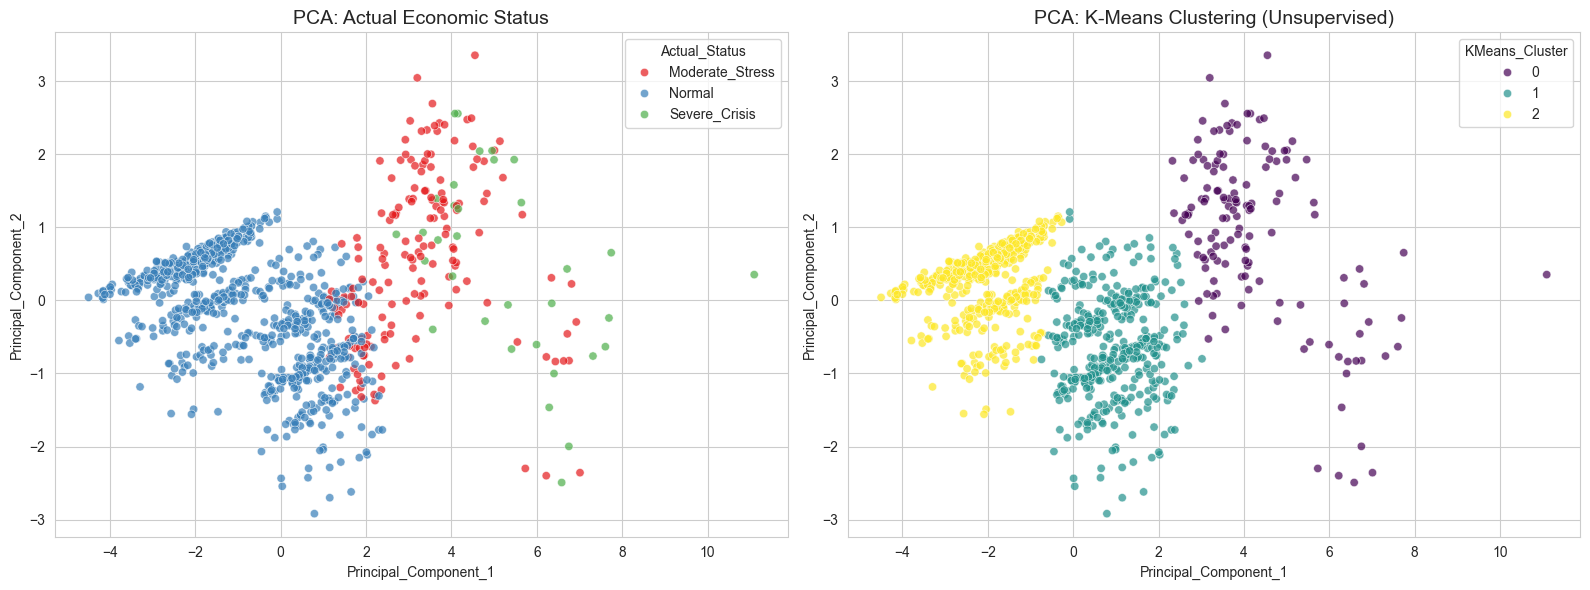

In [28]:
# 5. ප්‍රතිඵල ප්‍රස්ථාරගත කිරීම
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# අතින් හදපු (සැබෑ) ලේබල් වලට අනුව
sns.scatterplot(x='Principal_Component_1', y='Principal_Component_2', hue='Actual_Status', data=df_pca, palette='Set1', alpha=0.7, ax=axes[0])
axes[0].set_title('PCA: Actual Economic Status', fontsize=14)

# ML Model එක තනියම හොයාගත්ත කණ්ඩායම් වලට අනුව
sns.scatterplot(x='Principal_Component_1', y='Principal_Component_2', hue='KMeans_Cluster', data=df_pca, palette='viridis', alpha=0.7, ax=axes[1])
axes[1].set_title('PCA: K-Means Clustering (Unsupervised)', fontsize=14)

plt.tight_layout()
plt.show()

In [29]:
# මාන අඩු කිරීමෙන් අපි රැකගත්ත දත්ත ප්‍රතිශතය
print(f"Variance explained by PC1 and PC2: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Variance explained by PC1 and PC2: 80.11%


## 🧠 Phase 3: Supervised Learning (Logistic Regression & SVM)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
# 1. දත්ත වෙන් කිරීම (Features සහ Target)
# අපි අනාවැකි කියන්නේ ඩොලර් රේට් එක, ඩීසල් මිල, සහ කෝටාව පදනම් කරගෙන
X = df[['USD_Rate', 'Diesel_Price_Rs', 'Lorry_Quota_L', 'Rice_Price_Rs']]
X.head()

,USD_Rate,Diesel_Price_Rs,Lorry_Quota_L,Rice_Price_Rs
0,320.70,402.80,150.0,236.65
1,311.18,387.10,156.0,229.10
2,322.97,392.01,158.0,226.47
3,336.10,400.04,169.0,239.23
4,309.74,383.18,163.0,233.37


In [36]:
y = df['Power_Cut_Warning']
y.head()

0    0
1    0
2    0
3    1
4    0
Name: Power_Cut_Warning, dtype: int64

In [37]:
# 2. Scaling (SVM වලට මේක අනිවාර්යයි!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
# 3. Train/Test Split (80% Train කරන්න, 20% Test කරන්න)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [39]:
# ==========================================
# Model 1: Logistic Regression
# ==========================================
# class_weight='balanced' දාන්නේ විදුලිය කැපෙන දවස් ගාණ අඩු නිසා, ඒකට වැඩි බරක් දෙන්න.
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

In [40]:
# ==========================================
# Model 2: Support Vector Machine (RBF Kernel)
# ==========================================

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [44]:
# ==========================================
# ප්‍රතිඵල පෙන්වීම (Evaluation)
# ==========================================

print("--- 📈 Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))



--- 📈 Logistic Regression Results ---
Accuracy: 0.9850
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       171
           1       0.91      1.00      0.95        29

    accuracy                           0.98       200
   macro avg       0.95      0.99      0.97       200
weighted avg       0.99      0.98      0.99       200



In [43]:
print("\n--- 🚀 SVM (RBF Kernel) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


--- 🚀 SVM (RBF Kernel) Results ---
Accuracy: 0.9900
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       171
           1       0.94      1.00      0.97        29

    accuracy                           0.99       200
   macro avg       0.97      0.99      0.98       200
weighted avg       0.99      0.99      0.99       200



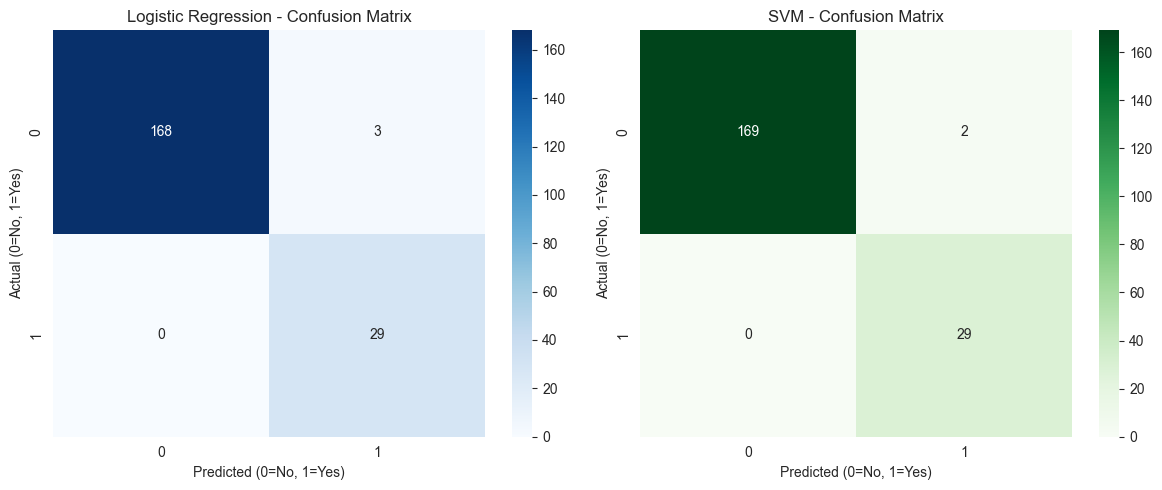

In [45]:
# Confusion Matrix ප්‍රස්ථාර ඇඳීම
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted (0=No, 1=Yes)')
axes[0].set_ylabel('Actual (0=No, 1=Yes)')

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('SVM - Confusion Matrix')
axes[1].set_xlabel('Predicted (0=No, 1=Yes)')
axes[1].set_ylabel('Actual (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

## 🚀 Phase 4: Hyperparameter Tuning (GridSearchCV)

In [46]:
from sklearn.model_selection import GridSearchCV

In [47]:
print("Running GridSearchCV to find the optimal SVM parameters...")
print("(This might take a few seconds...)")

# 1. පරීක්ෂා කළ යුතු අගයන් ලැයිස්තුව (Parameter Grid)
param_grid = {
    'C': [0.1, 1, 10, 100],          # C කුඩා නම් නියාමනය වැඩියි, විශාල නම් Overfit වෙන්න පුළුවන්
    'gamma': [0.01, 0.1, 1, 'scale'] # RBF Kernel එකේ සුමට බව (Smoothness)
}

Running GridSearchCV to find the optimal SVM parameters...
(This might take a few seconds...)


In [49]:
# 2. GridSearchCV එක සෑදීම
# cv=5 කියන්නේ 5-fold cross validation. දත්ත කොටස් 5 කට කඩලා 5 පාරක් ටෙස්ට් කරනවා.
grid_search = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=5, scoring='accuracy')

# 3. Model එක Train කිරීම
grid_search.fit(X_train, y_train)

# 4. හොඳම ප්‍රතිඵල පෙන්වීම
print("\n✅ Grid Search Completed!")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


✅ Grid Search Completed!
Best Parameters Found: {'C': 100, 'gamma': 'scale'}
Best Cross-Validation Accuracy: 0.9900


In [50]:
# හොඳම Model එකෙන් Test Data ටික ආයේ ටෙස්ට් කරමු
best_svm = grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test)

print("\n--- 🌟 Best SVM Model Results on Test Data ---")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred_best_svm):.4f}")
print(classification_report(y_test, y_pred_best_svm))


--- 🌟 Best SVM Model Results on Test Data ---
Final Test Accuracy: 0.9950
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       171
           1       1.00      0.97      0.98        29

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200

